<a href="https://colab.research.google.com/github/ansuman1981/SEA-Inequality-Research/blob/main/SEA_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# import the packages
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as mp

#load th dataset
df = pd.read_excel("/content/SEA_Master_Data_FINAL.xlsx")
print(df.shape)
print(df.head(10))
print(df.dtypes)

(144, 5)
  Code    Country  Year  KOFGI  Gini
0  IDN  Indonesia  2000   60.0  30.3
1  IDN  Indonesia  2001   60.2  31.2
2  IDN  Indonesia  2002   57.1  30.2
3  IDN  Indonesia  2003   57.5  29.3
4  IDN  Indonesia  2004   59.6  30.4
5  IDN  Indonesia  2005   61.2  29.9
6  IDN  Indonesia  2006   60.9  31.5
7  IDN  Indonesia  2007   61.5  33.2
8  IDN  Indonesia  2008   60.2  32.6
9  IDN  Indonesia  2009   59.6  33.4
Code        object
Country     object
Year         int64
KOFGI      float64
Gini       float64
dtype: object


In [12]:
# Define one consistent color for each country
# These colors will be used across ALL charts so the reader
# can identify each country without re-reading the legend every time
country_colors = {
    'Indonesia':   '#CE1126',   # Indonesia — flag red
    'Malaysia':    '#FFCC00',   # Malaysia — flag yellow
    'Philippines': '#0038A8',   # Philippines — flag blue
    'Singapore':   '#FF6B9D',   # Singapore — lighter pink-red (distinct from Indonesia)
    'Thailand':    '#241D4F',   # Thailand — flag navy
    'Viet Nam':    '#44A854',   # Vietnam — represents the green fields (distinct from yellow)
}

print("Countries are in dataset:",df["Country"].unique())
print("color maping ready for:", list (country_colors.keys()))

Countries are in dataset: ['Indonesia' 'Malaysia' 'Philippines' 'Singapore' 'Thailand' 'Viet Nam']
color maping ready for: ['Indonesia', 'Malaysia', 'Philippines', 'Singapore', 'Thailand', 'Viet Nam']
{country}:{color}
{country}:{color}
{country}:{color}
{country}:{color}
{country}:{color}
{country}:{color}


In [13]:
# Flag-inspired colors — each country gets its most distinctive flag color
# Adjusted slightly so no two countries look the same on a chart

country_colors = {
    'Indonesia':   '#CE1126',   # Indonesia — flag red
    'Malaysia':    '#FFCC00',   # Malaysia — flag yellow
    'Philippines': '#0038A8',   # Philippines — flag blue
    'Singapore':   '#FF6B9D',   # Singapore — pink-red (distinct from Indonesia)
    'Thailand':    '#241D4F',   # Thailand — flag navy blue
    'Viet Nam':    '#44A854',   # Vietnam — green (distinct, represents growth)
}

# Test the colors by printing them
for country, color in country_colors.items():
    print(f"{country}: {color}")

Indonesia: #CE1126
Malaysia: #FFCC00
Philippines: #0038A8
Singapore: #FF6B9D
Thailand: #241D4F
Viet Nam: #44A854


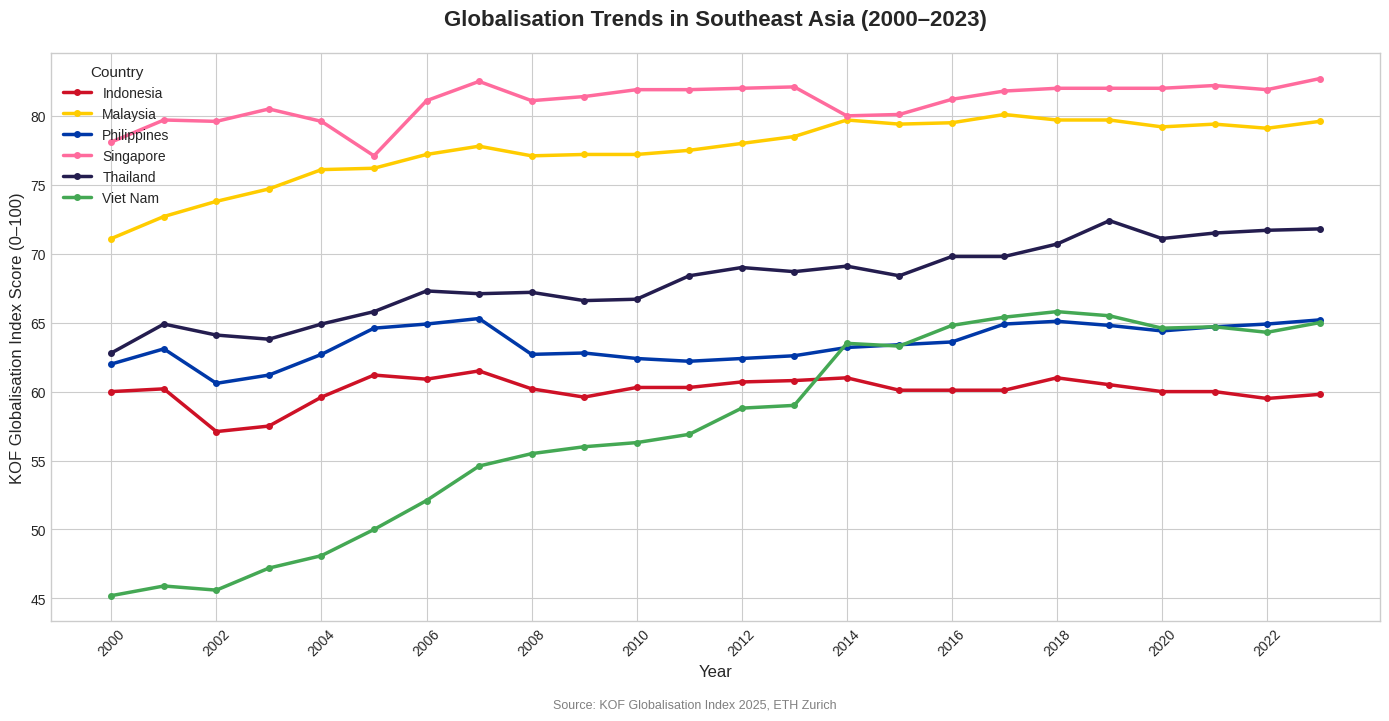

Chart 1 saved successfully


In [14]:
# ============================================
# CHART 1 — Globalisation Trends Over Time
# Question: How did globalisation change across
# 6 SEA countries from 2000 to 2023?
# ============================================

# Set the overall style of the chart — white background, clean grid
plt.style.use('seaborn-v0_8-whitegrid')

# Create the figure — sets the canvas size (width=14, height=7 inches)
fig, ax = plt.subplots(figsize=(14, 7))

# Loop through each country and plot its KOFGI line
for country, color in country_colors.items():

    # Filter dataframe to get only rows for this country
    country_data = df[df['Country'] == country]

    # Plot a line for this country
    # x = Year, y = KOFGI score, color = flag color, linewidth = thickness
    ax.plot(country_data['Year'],
            country_data['KOFGI'],
            color=color,
            linewidth=2.5,
            marker='o',        # Small dot at each data point
            markersize=4,      # Size of the dot
            label=country)     # Label used in legend

# Add chart title and axis labels
ax.set_title('Globalisation Trends in Southeast Asia (2000–2023)',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('KOF Globalisation Index Score (0–100)', fontsize=12)

# Set x-axis to show every 2 years
ax.set_xticks(range(2000, 2024, 2))

# Rotate x-axis labels so they don't overlap
plt.xticks(rotation=45)

# Add legend — shows which color = which country
ax.legend(title='Country', fontsize=10, title_fontsize=11,
          loc='upper left')

# Add a note about the data source at the bottom
fig.text(0.5, -0.02, 'Source: KOF Globalisation Index 2025, ETH Zurich',
         ha='center', fontsize=9, color='gray')

# Tight layout so nothing gets cut off
plt.tight_layout()

# Save the chart as a high resolution PNG file
plt.savefig('chart1_globalisation_trends.png', dpi=300, bbox_inches='tight')

# Display the chart in Colab
plt.show()


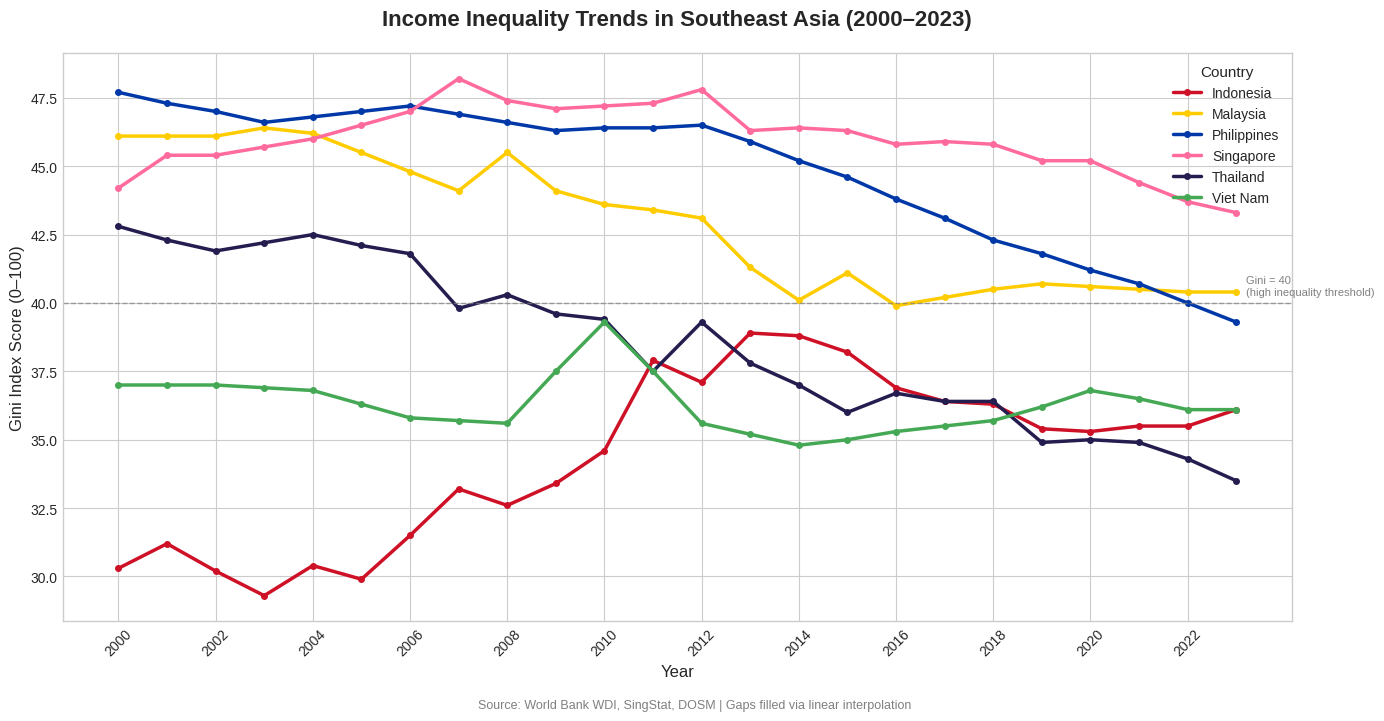

Chart 2 saved successfully


In [15]:
# ============================================
# CHART 2 — Inequality Trends Over Time
# Question: How did income inequality change
# across 6 SEA countries from 2000 to 2023?
# ============================================

# Create the figure
fig, ax = plt.subplots(figsize=(14, 7))

# Loop through each country and plot its Gini line
for country, color in country_colors.items():

    # Filter data for this country
    country_data = df[df['Country'] == country]

    # Plot the Gini line for this country
    ax.plot(country_data['Year'],
            country_data['Gini'],
            color=color,
            linewidth=2.5,
            marker='o',       # Dot at each data point
            markersize=4,
            label=country)

# Add title and axis labels
ax.set_title('Income Inequality Trends in Southeast Asia (2000–2023)',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Gini Index Score (0–100)', fontsize=12)

# Set x-axis ticks every 2 years
ax.set_xticks(range(2000, 2024, 2))
plt.xticks(rotation=45)

# Add a horizontal reference line at Gini = 40
# This is a commonly used threshold in development economics
# Above 40 = high inequality, below 40 = moderate inequality
ax.axhline(y=40, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.text(2023.2, 40.3, 'Gini = 40\n(high inequality threshold)',
        fontsize=8, color='gray')

# Add legend
ax.legend(title='Country', fontsize=10, title_fontsize=11,
          loc='upper right')

# Add data source note
fig.text(0.5, -0.02,
         'Source: World Bank WDI, SingStat, DOSM | Gaps filled via linear interpolation',
         ha='center', fontsize=9, color='gray')

plt.tight_layout()

# Save as high resolution PNG
plt.savefig('chart2_gini_trends.png', dpi=300, bbox_inches='tight')

plt.show()
